# The East African Automotive Logistics Engine

##  Introduction

Njogu Enterprises is planning to venture into the automobile sales industry. As a new entrant in the market, the company seeks to understand customer preferences, market trends, and the characteristics of vehicles that attract the highest demand. Making informed decisions at this stage is essential to ensure that the company invests in vehicle categories that are most likely to generate sales and long-term profitability.

The primary question guiding this analysis is:

**What types of vehicles are most popular in the market, and which vehicle characteristics should Njogu Enterprises focus on when building its inventory?**

To answer this question, automobile market data will be analyzed to identify patterns in vehicle pricing, fuel type, transmission type, age, mileage, brand popularity, and other relevant factors. The analysis will use data visualization and exploratory data analysis techniques to uncover customer preferences and market demand.

The insights generated from this study will help Njogu Enterprises make data-driven decisions regarding the types of vehicles to stock, target customer segments, and pricing strategies. Ultimately, the findings will support the company's goal of entering the automobile market with a competitive and profitable product offering.


# Importing Libraries

In [25]:
#Required Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
pd.set_option("display.max_columns", None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)
df = pd.read_csv("CARDETAILSFROMCARDEKHO.csv")
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


## Dataset Description

The dataset contains information about used cars listed for sale. Each row represents a single vehicle and includes details about its characteristics, ownership history, and selling price.

### Column Descriptions

* **name**: The brand and model name of the vehicle (e.g., Toyota Corolla, Honda Civic).

* **year**: The year in which the vehicle was manufactured.

* **selling_price**: The price at which the vehicle is being sold.

* **km_driven**: The total distance the vehicle has traveled, measured in kilometers.

* **fuel**: The type of fuel used by the vehicle, such as Petrol, Diesel, CNG, or LPG.

* **seller_type**: The category of the seller, such as an individual owner, dealer, or trustmark dealer.

* **transmission**: The type of transmission system in the vehicle, either Manual or Automatic.

* **owner**: Indicates the ownership history of the vehicle, such as First Owner, Second Owner, Third Owner, or Test Drive Car.


In [28]:
df.isnull().sum()

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

From this it is very clear that our dataset does not contain any missing values hence no point of trying to clean thhe dataset.

In [29]:
df.duplicated().sum()

np.int64(763)

Our dataset contains 763 duplicated values which have to be dropped,

In [30]:
df = df.drop_duplicates()

In [31]:
df.duplicated().sum()

np.int64(0)

Now we are sure that our dataset does not contain any duplicates.

In [32]:
df.describe()

,year,selling_price,km_driven
count,3577.000,3577.000,3577.000
mean,2012.963,473912.542,69250.546
std,4.252,509301.810,47579.940
min,1992.000,20000.000,1.000
25%,2010.000,200000.000,36000.000
50%,2013.000,350000.000,60000.000
75%,2016.000,600000.000,90000.000
max,2020.000,8900000.000,806599.000


From the describe we can evidently see that there are outliers in both the selling price and km driven by just looking at the min, max and 75%. To be more precise on this we are going to use a boxplot to try and understand this more.

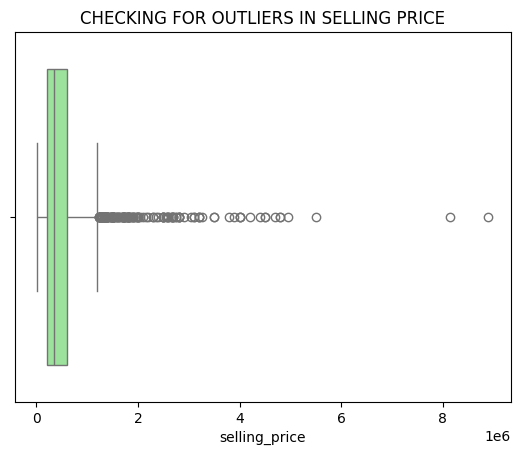

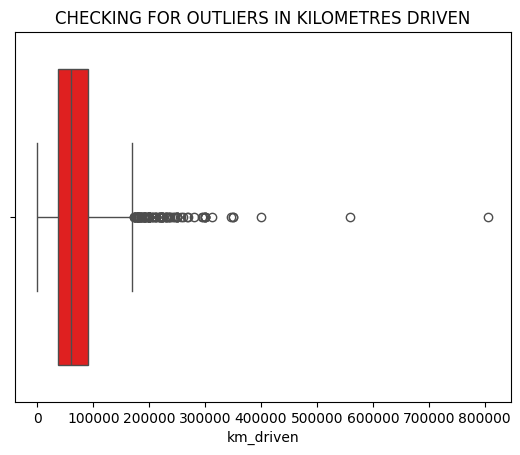

In [33]:
sns.boxplot(data = df, x = "selling_price", color = "lightgreen")
plt.title("CHECKING FOR OUTLIERS IN SELLING PRICE")
plt.show()

sns.boxplot(data = df, x = "km_driven", color = "red")
plt.title("CHECKING FOR OUTLIERS IN KILOMETRES DRIVEN")
plt.show()

In [34]:
df = df[(df["selling_price"] >= 100000) & (df["selling_price"] <= 3500000)]
df = df[(df["km_driven"] >= 10000) & (df["km_driven"] <= 300000)]

Logically it is impossible to find a car that costs less than 100000 so we capped the selling price at 100000 and the maximum at 3.5 million as the cars which costs insane prices are outliers in our data and besides our company wants affordable cars. For kilometres driven our min was 1, that does not count as a new car but in our data it will cause an outlier.


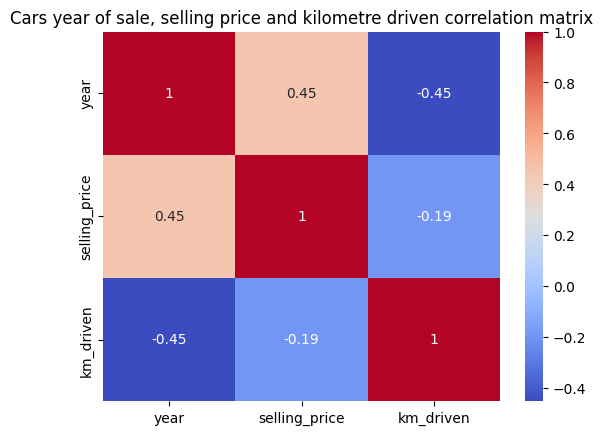

In [35]:
numeric_df = df[["year","selling_price", "km_driven"]]

numeric_corr = numeric_df.corr()

sns.heatmap(numeric_corr, annot=True,cmap="coolwarm")
plt.title("Cars year of sale, selling price and kilometre driven correlation matrix")
plt.show()

The analysis suggests that:

Newer vehicles generally sell at higher prices.
Newer vehicles tend to have lower mileage.
Mileage has some effect on price, but it is relatively weak compared to vehicle age.


In [36]:
df["car_age"] = 2026 - df["year"]

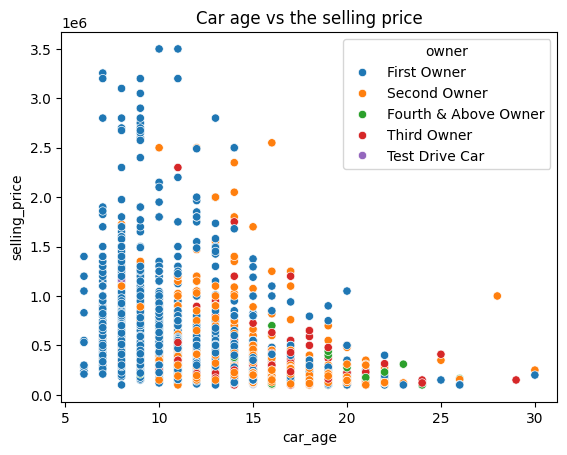

In [39]:
sns.scatterplot(data=df, x = "car_age", y = "selling_price", hue="owner")
plt.title("Car age vs the selling price")
plt.show()

From the scatter plot, it is evident that vehicles aged between 5 and 15 years account for a large proportion of the listings and continue to command relatively good selling prices. This suggests strong market demand for vehicles within this age range. Therefore, Njogu Enterprises should consider focusing on importing and stocking vehicles that are between 5 and 15 years old, as they appear to offer a balance between affordability for customers and profitability for the business.Customers also seem to be more interested in vehicles in which they would be the second owner.

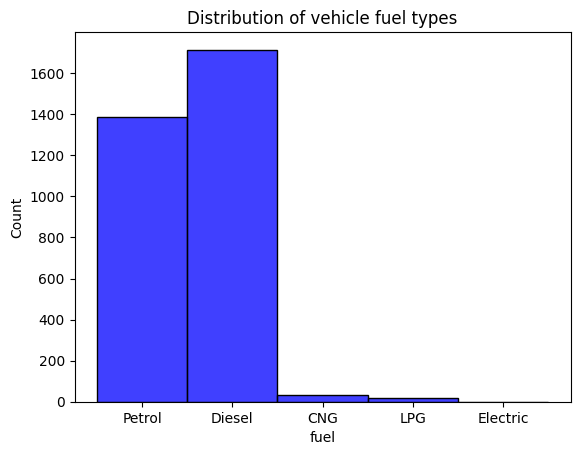

In [38]:
sns.histplot(data=df, x= "fuel", bins=20, color="blue")
plt.title("Distribution of vehicle fuel types")
plt.show()

Based on our histogram plot vehicles powered by Petrol and Diesel account for the largest part in the market. It is hence recommended for the company to focus more on petrol and diesel powered vehicles.

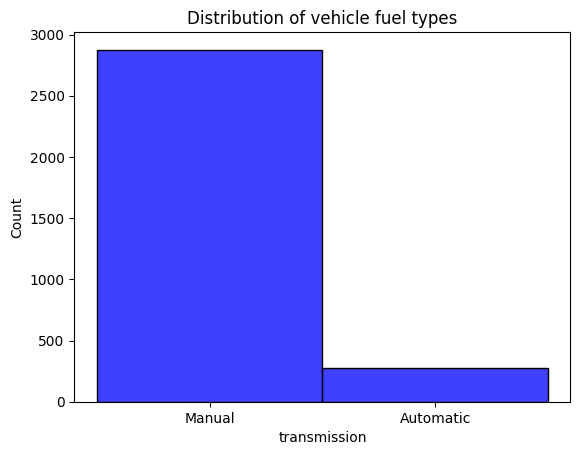

In [40]:
sns.histplot(data=df, x= "transmission", bins=20, color="blue")
plt.title("Distribution of vehicle fuel types")
plt.show()

The distribution of vehicle transmission types shows that manual transmission vehicles dominate the market, accounting for the vast majority of cars in the dataset. Automatic transmission vehicles represent only a small proportion of the listings. This suggests that customer demand and market availability are currently much higher for manual vehicles. Therefore, Njogu Enterprises should prioritize stocking manual transmission vehicles while maintaining a smaller inventory of automatic vehicles to cater to specific customer preferences.

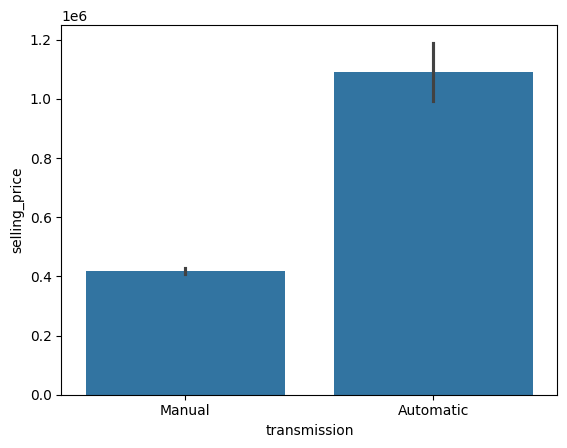

In [ ]:
sns.barplot(data=df, x = "transmission", y="selling_price")
plt.title("Transmission type VS selling price")
plt.show()

The analysis reveals that while manual transmission vehicles dominate the market in terms of availability, automatic vehicles achieve considerably higher average selling prices. This suggests that manual vehicles may offer higher sales volume opportunities, whereas automatic vehicles may provide higher profit margins. A balanced inventory strategy incorporating both transmission types would therefore be beneficial for Njogu Enterprises.